In [343]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import scipy.stats as stats
import matplotlib.pyplot as plt

# ==========================================
# 🔧 STEP 1: MASTER CONFIGURATION
# ==========================================
# 1. File & Device Settings
FILENAME = '../Python_tools/s10_sit_three_cols.csv'
FS = 400.0                   

# 2. ✂️ DATA SELECTION
SAMPLE_START = 32000           
SAMPLE_END   = 34000          

# 3. Thresholds (Validity Check)
THRESHOLD_RED = 1000
THRESHOLD_IR  = 1000

# 4. Filter Settings
KERNEL_SIZE = 1              # Spike Removal (Odd Number)
NORM_METHOD = "MINMAX"       # "ZSCORE" (Rec.) or "MINMAX"

# --- Low Pass Settings (Noise Removal) ---
LP_CUTOFF = 16.0             # Low Pass Frequency
LP_ORDER = 4                 # Filter Order

# --- High Pass Settings (Baseline Drift Removal) ---
HP_ENABLE = True             # ⚡ SET THIS TO FALSE TO TURN OFF HIGH PASS
HP_CUTOFF = 0.5              # 0.5 Hz is standard for removing breathing drift
HP_ORDER  = 4                # Filter Order

# --- Inversion Settings (NEW!) ---
INVERT_ENABLE = True         # ⚡ SET TO TRUE IF SIGNAL IS UPSIDE DOWN

# --- Savitzky-Golay Settings (The "Peak Protector") ---
SG_ENABLE = True             # Set to False to disable
SG_WINDOW = 31                # Must be ODD (5, 7, 9, 11). Small = Sharp Peaks.
SG_POLY   = 3                # Polynomial Order (2 or 3 is standard)

# ==========================================
# 🛠️ HELPER FUNCTIONS
# ==========================================
def apply_normalization(data, method="ZSCORE"):
    if len(data) == 0: return data
    if method == "MINMAX":
        return (data - np.min(data)) / (np.max(data) - np.min(data))
    elif method == "ZSCORE":
        return (data - np.mean(data)) / np.std(data)
    return data

# ==========================================
# 📐 AUTOMATIC CALCULATIONS (NEW!)
# ==========================================
# 1. Calculate Total Plot Time (Duration in Seconds)
total_samples = SAMPLE_END - SAMPLE_START
plot_time = total_samples / FS

# 2. Calculate Nyquist Rate (The Frequency Limit)
nyquist_rate = FS / 2.0

print("✅ Configuration Loaded.")
print(f"📍 Range Selected: {SAMPLE_START} to {SAMPLE_END} ({total_samples} samples)")
print(f"⏱️  Total Plot Time: {plot_time:.2f} seconds")
print(f"📉 Nyquist Rate:   {nyquist_rate:.1f} Hz")
print(f"✅ Inversion Enabled: {INVERT_ENABLE}")

✅ Configuration Loaded.
📍 Range Selected: 32000 to 34000 (2000 samples)
⏱️  Total Plot Time: 5.00 seconds
📉 Nyquist Rate:   200.0 Hz
✅ Inversion Enabled: True


✅ Processing Range: 2000 samples.


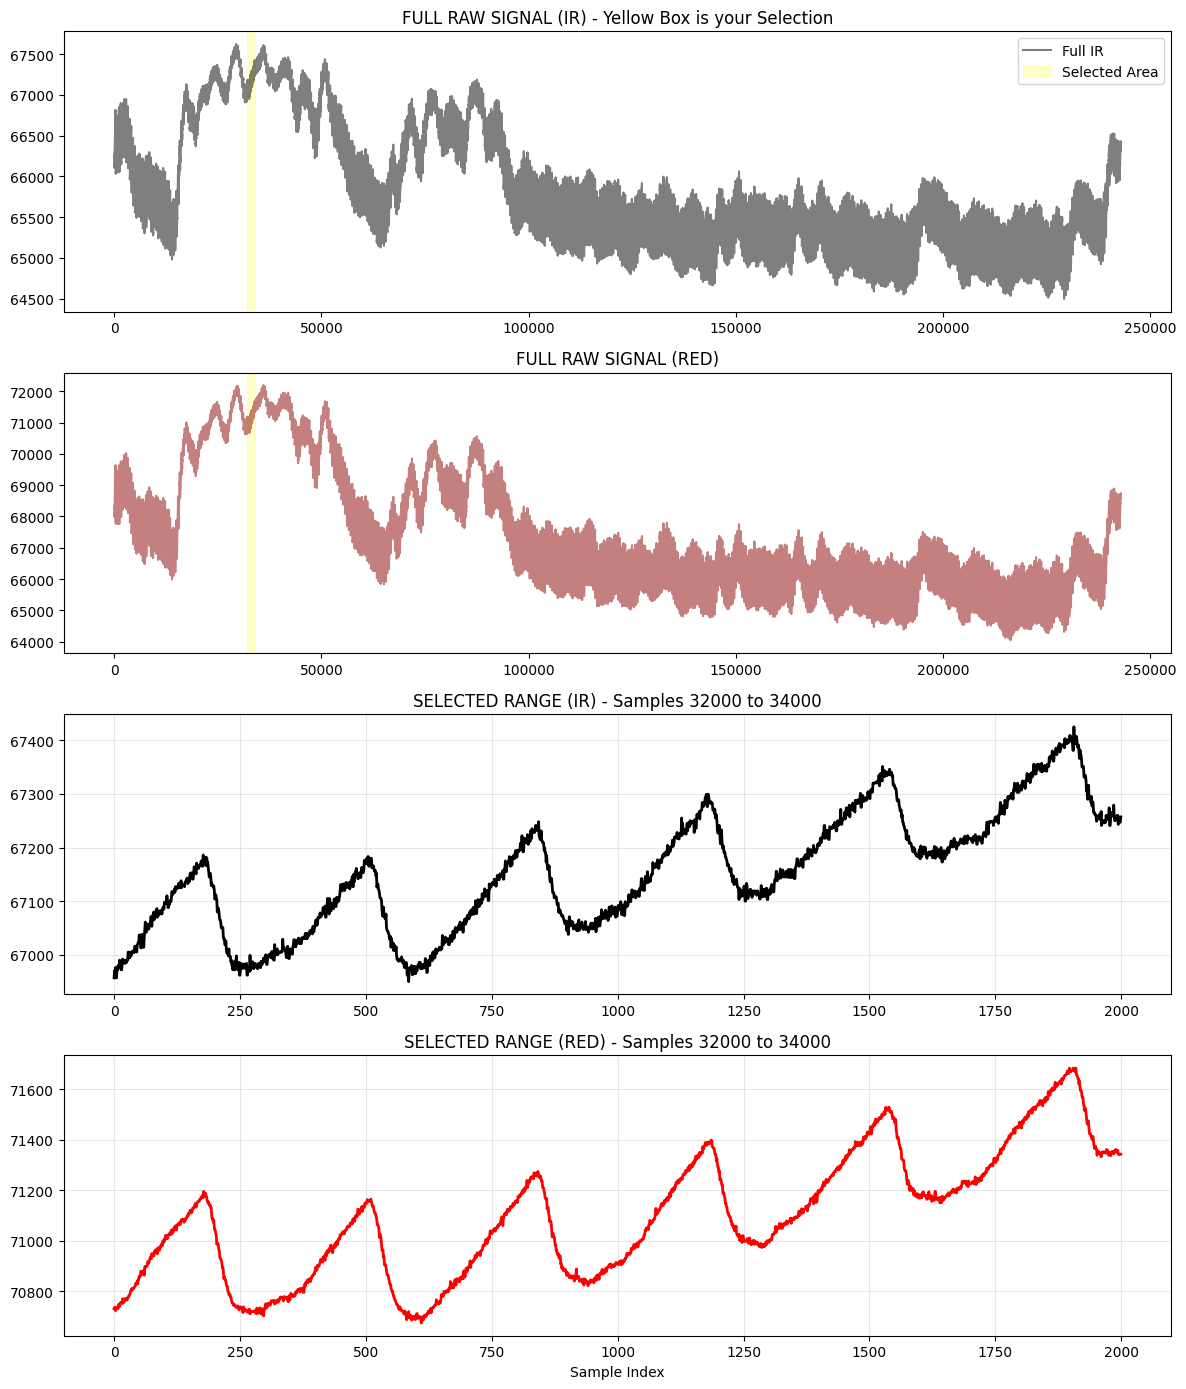

In [344]:
# ==========================================
# ⚙️ STEP 2: LOAD, SELECT & PLOT RAW
# ==========================================
# 1. Load CSV
df = pd.read_csv(FILENAME)
df.columns = df.columns.str.strip().str.upper()
rename_map = {'RED_VALUE': 'RED', 'IR_VALUE': 'IR', 'RED VALUE': 'RED', 'IR VALUE': 'IR'}
df = df.rename(columns=rename_map)

# 2. Apply Thresholds (Validity Check)
mask = (df['RED'] > THRESHOLD_RED) & (df['IR'] > THRESHOLD_IR)
full_clean_df = df[mask].copy()

# 3. ✂️ APPLY SELECTION (Slicing)
# We create a new DataFrame 'selected_df' that contains ONLY your range
if SAMPLE_END is None:
    selected_df = full_clean_df.iloc[SAMPLE_START:].copy()
else:
    selected_df = full_clean_df.iloc[SAMPLE_START:SAMPLE_END].copy()

# Safety Check
if len(selected_df) < 50:
    print(f"❌ CRITICAL ERROR: Selected range is too short ({len(selected_df)} samples)!")
else:
    print(f"✅ Processing Range: {len(selected_df)} samples.")

    # --- PLOTTING ---
    fig, axes = plt.subplots(4, 1, figsize=(12, 14))

    # Plot 1: FULL Data (IR)
    axes[0].plot(full_clean_df['IR'].values, color='black', alpha=0.5, label='Full IR')
    axes[0].axvspan(SAMPLE_START, SAMPLE_END if SAMPLE_END else len(full_clean_df), color='yellow', alpha=0.2, label='Selected Area')
    axes[0].set_title('FULL RAW SIGNAL (IR) - Yellow Box is your Selection')
    axes[0].legend()

    # Plot 2: FULL Data (RED)
    axes[1].plot(full_clean_df['RED'].values, color='darkred', alpha=0.5, label='Full RED')
    axes[1].axvspan(SAMPLE_START, SAMPLE_END if SAMPLE_END else len(full_clean_df), color='yellow', alpha=0.2)
    axes[1].set_title('FULL RAW SIGNAL (RED)')
    
    # Plot 3: SELECTED Data (IR)
    axes[2].plot(selected_df['IR'].values, color='black', linewidth=2, label='Selected IR')
    axes[2].set_title(f'SELECTED RANGE (IR) - Samples {SAMPLE_START} to {SAMPLE_END}')
    axes[2].grid(True, alpha=0.3)

    # Plot 4: SELECTED Data (RED)
    axes[3].plot(selected_df['RED'].values, color='red', linewidth=2, label='Selected RED')
    axes[3].set_title(f'SELECTED RANGE (RED) - Samples {SAMPLE_START} to {SAMPLE_END}')
    axes[3].grid(True, alpha=0.3)
    axes[3].set_xlabel('Sample Index')

    plt.tight_layout()
    plt.show()

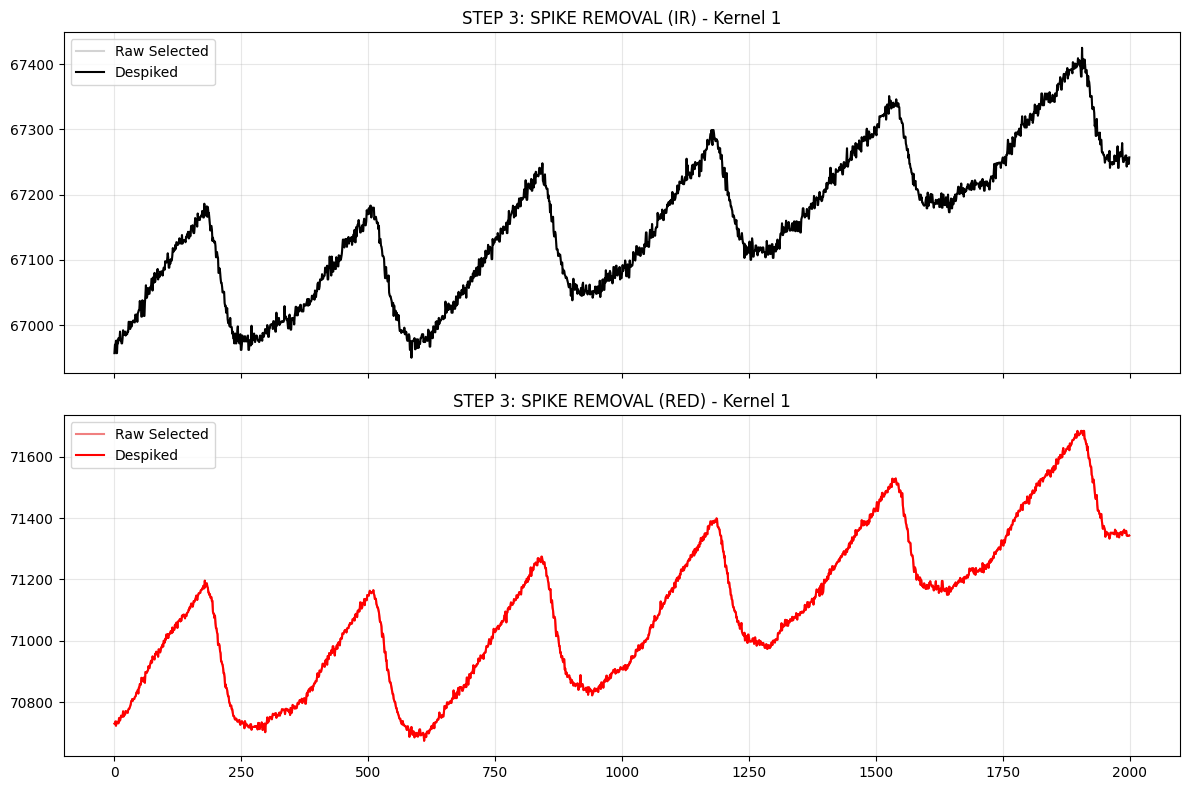

In [345]:
# ==========================================
# ⚙️ STEP 3: SPIKE REMOVAL
# ==========================================
# Apply Median Filter to the SELECTED data
ir_despiked  = signal.medfilt(selected_df['IR'].values, kernel_size=KERNEL_SIZE)
red_despiked = signal.medfilt(selected_df['RED'].values, kernel_size=KERNEL_SIZE)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(selected_df['IR'].values, color='lightgray', label='Raw Selected')
ax1.plot(ir_despiked, color='black', linewidth=1.5, label='Despiked')
ax1.set_title(f'STEP 3: SPIKE REMOVAL (IR) - Kernel {KERNEL_SIZE}')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(selected_df['RED'].values, color='lightcoral', label='Raw Selected')
ax2.plot(red_despiked, color='red', linewidth=1.5, label='Despiked')
ax2.set_title(f'STEP 3: SPIKE REMOVAL (RED) - Kernel {KERNEL_SIZE}')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

🔄 INVERSION APPLIED: Flipping signal so Systolic Peak points UP.


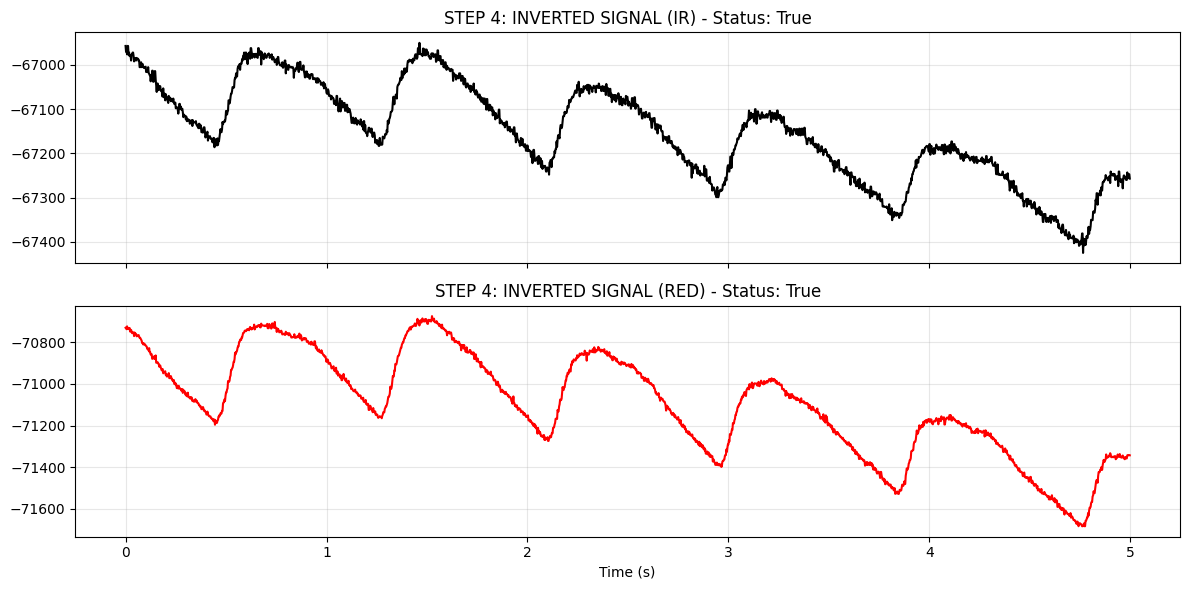

In [346]:
# ==========================================
# ⚙️ STEP 4: SIGNAL INVERSION (Fixes Morphology)
# ==========================================
# Input: red_despiked / ir_despiked (From Step 3)
# Output: red_inverted / ir_inverted (Goes to Step 5)

if INVERT_ENABLE:
    print("🔄 INVERSION APPLIED: Flipping signal so Systolic Peak points UP.")
    red_inverted = red_despiked * -1
    ir_inverted  = ir_despiked * -1
else:
    print("➡️ INVERSION SKIPPED: Passing signal through.")
    red_inverted = red_despiked
    ir_inverted  = ir_despiked

# Plot to confirm
t = np.arange(len(red_inverted)) / FS
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(t, ir_inverted, color='black')
ax1.set_title(f'STEP 4: INVERTED SIGNAL (IR) - Status: {INVERT_ENABLE}')
ax1.grid(True, alpha=0.3)

ax2.plot(t, red_inverted, color='red')
ax2.set_title(f'STEP 4: INVERTED SIGNAL (RED) - Status: {INVERT_ENABLE}')
ax2.set_xlabel('Time (s)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

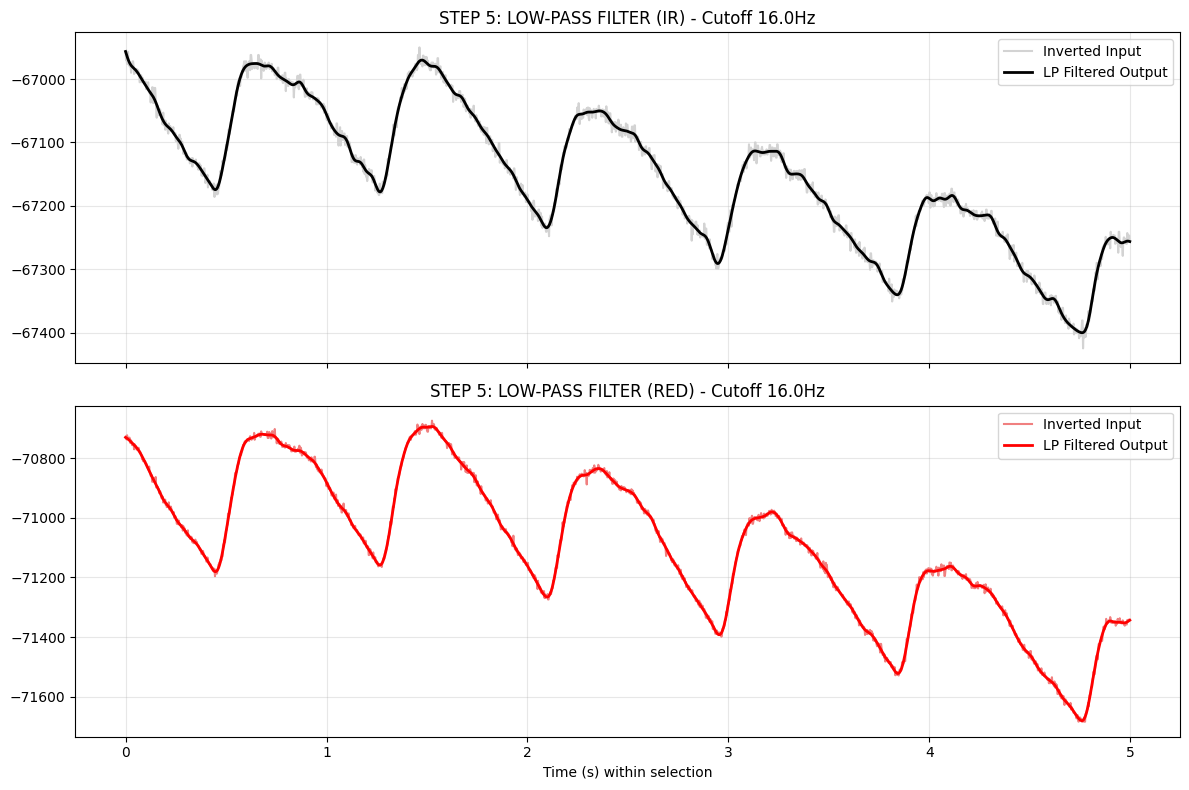

In [347]:
# ==========================================
# ⚙️ STEP 5: LOW-PASS FILTER
# ==========================================
# Input: red_inverted / ir_inverted (From Step 4)
# Output: red_filtered / ir_filtered

nyquist = 0.5 * FS
sos = signal.butter(LP_ORDER, LP_CUTOFF / nyquist, btype='low', output='sos')

# Applying filter to the INVERTED signal (Updated Input)
red_filtered = signal.sosfiltfilt(sos, red_inverted)
ir_filtered  = signal.sosfiltfilt(sos, ir_inverted)

# Plot for Step 5
t = np.arange(len(red_filtered)) / FS 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(t, ir_inverted, color='lightgray', label='Inverted Input')
ax1.plot(t, ir_filtered, color='black', linewidth=2, label='LP Filtered Output')
ax1.set_title(f'STEP 5: LOW-PASS FILTER (IR) - Cutoff {LP_CUTOFF}Hz')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(t, red_inverted, color='lightcoral', label='Inverted Input')
ax2.plot(t, red_filtered, color='red', linewidth=2, label='LP Filtered Output')
ax2.set_title(f'STEP 5: LOW-PASS FILTER (RED) - Cutoff {LP_CUTOFF}Hz')
ax2.set_xlabel('Time (s) within selection')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

✨ Applying Savitzky-Golay Filter (Window: 31, Poly: 3)...


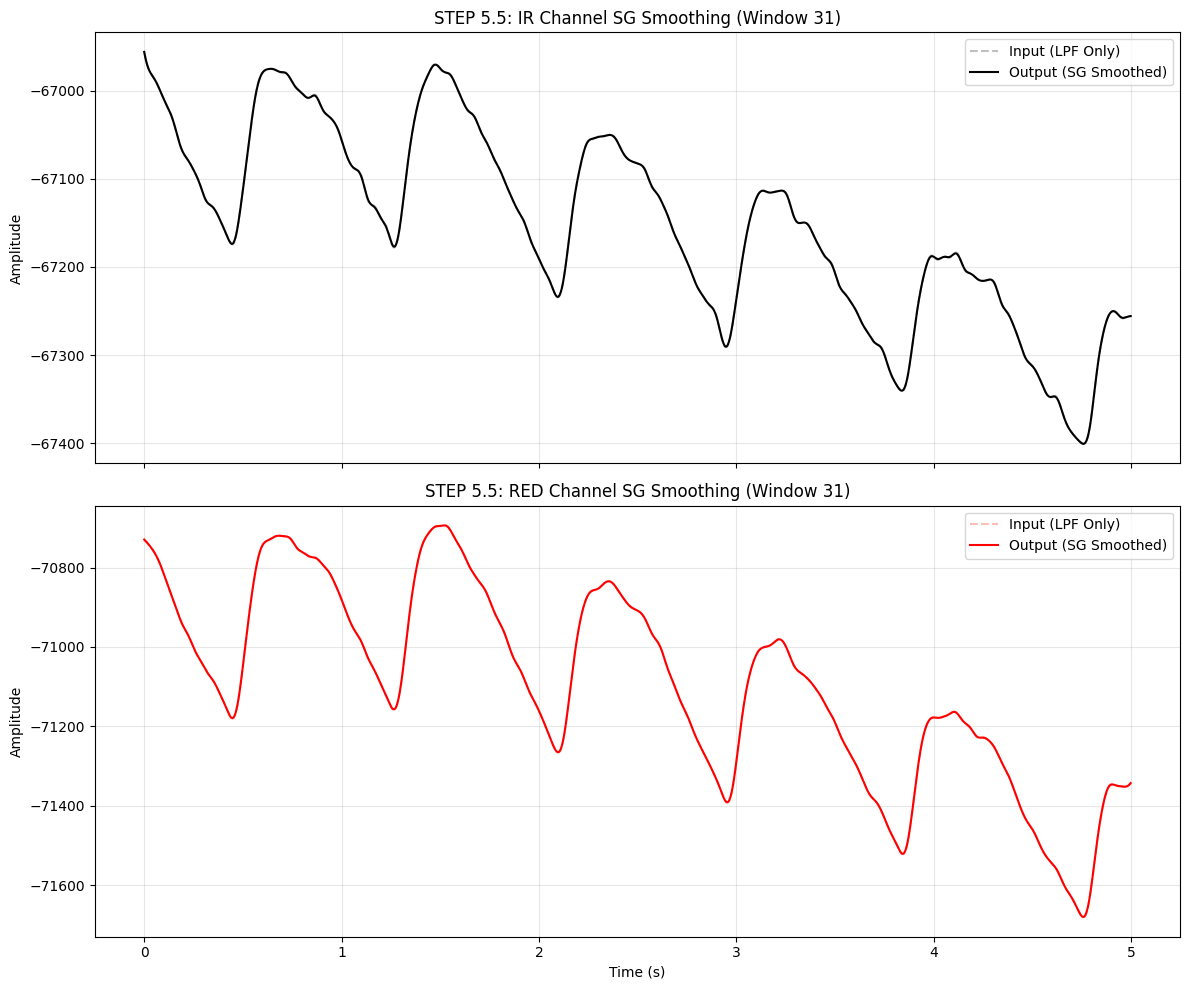

✅ Signal Smoothed. Ready for Step 6 (High Pass).


In [348]:
# ==========================================
# ⚙️ STEP 5.5: SAVITZKY-GOLAY SMOOTHING (Intermediate Polish)
# ==========================================
# Input: red_filtered / ir_filtered (Output from Step 5 LPF)
# Output: red_filtered / ir_filtered (Updated for Step 6 HPF)

# --- 1. Safety Check (Prevents Crashes) ---
safe_window = int(SG_WINDOW)
safe_poly   = int(SG_POLY)

# Rule: Window must be ODD
if safe_window % 2 == 0:
    safe_window += 1
    print(f"⚠️ Adjusted SG_WINDOW to {safe_window} (Must be ODD)")

# Rule: Window must be bigger than Poly Order
if safe_window <= safe_poly:
    safe_window = safe_poly + 2
    if safe_window % 2 == 0: safe_window += 1
    print(f"⚠️ Adjusted SG_WINDOW to {safe_window} (Must be > Poly Order)")

# --- 2. Apply Filter (Update Variable In-Place) ---
# We store the 'Old' version just for plotting comparison
red_lpf_only = red_filtered.copy()
ir_lpf_only  = ir_filtered.copy()

if SG_ENABLE:
    print(f"✨ Applying Savitzky-Golay Filter (Window: {safe_window}, Poly: {safe_poly})...")
    
    # Overwrite 'red_filtered' so Step 6 uses this result automatically
    red_filtered = signal.savgol_filter(red_filtered, window_length=safe_window, polyorder=safe_poly)
    ir_filtered  = signal.savgol_filter(ir_filtered, window_length=safe_window, polyorder=safe_poly)
    
else:
    print("ℹ️ Savitzky-Golay Disabled. Passing signal through.")

# ==========================================
# 📊 PLOT COMPARISON
# ==========================================
# Calculate time for the WHOLE signal
t_full = np.arange(len(red_filtered)) / FS

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- Plot 1: IR Channel ---
ax1.plot(t_full, ir_lpf_only, color='gray', alpha=0.5, linestyle='--', label='Input (LPF Only)')
ax1.plot(t_full, ir_filtered, color='black', linewidth=1.5, label='Output (SG Smoothed)')
ax1.set_title(f"STEP 5.5: IR Channel SG Smoothing (Window {safe_window})")
ax1.set_ylabel("Amplitude")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Plot 2: RED Channel ---
ax2.plot(t_full, red_lpf_only, color='salmon', alpha=0.5, linestyle='--', label='Input (LPF Only)')
ax2.plot(t_full, red_filtered, color='red', linewidth=1.5, label='Output (SG Smoothed)')
ax2.set_title(f"STEP 5.5: RED Channel SG Smoothing (Window {safe_window})")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Amplitude")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Debug Print
print(f"✅ Signal Smoothed. Ready for Step 6 (High Pass).")

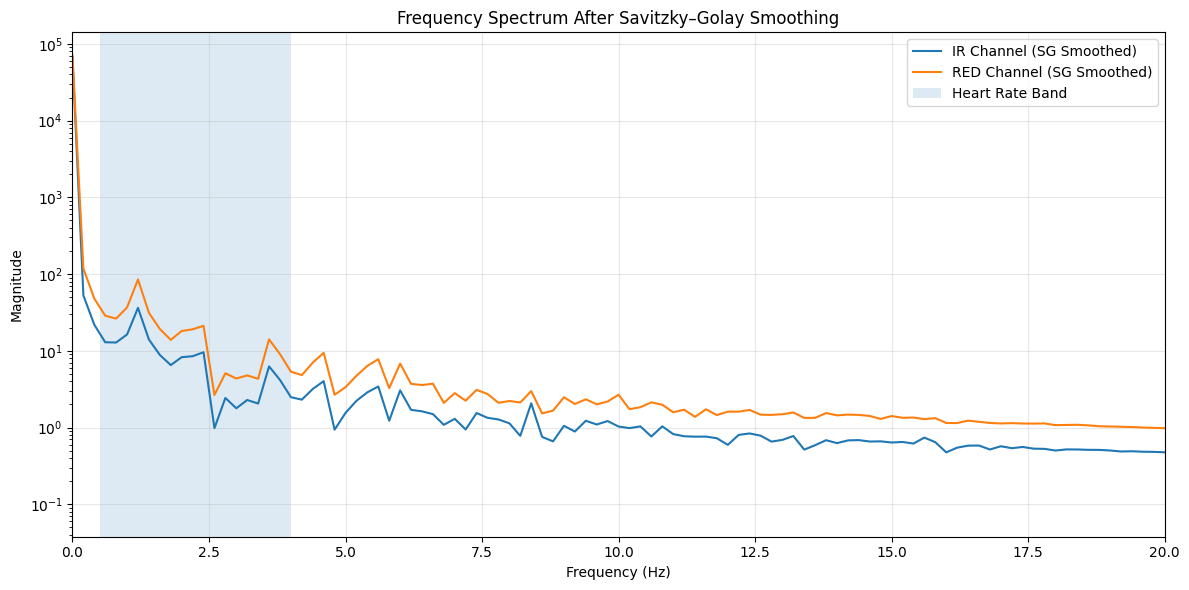

In [349]:
# ==========================================
# 📈 FREQUENCY DOMAIN ANALYSIS (FFT)
# ==========================================

def compute_fft(signal_data, fs):
    N = len(signal_data)
    fft_vals = np.fft.fft(signal_data)
    fft_vals = np.abs(fft_vals) / N
    freqs = np.fft.fftfreq(N, d=1/fs)
    return freqs[:N//2], fft_vals[:N//2]

# Compute FFTs
freq_ir, fft_ir = compute_fft(ir_filtered, FS)
freq_red, fft_red = compute_fft(red_filtered, FS)

# ==========================================
# 📊 FFT PLOTS
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(freq_ir, fft_ir, label='IR Channel (SG Smoothed)', linewidth=1.5)
plt.plot(freq_red, fft_red, label='RED Channel (SG Smoothed)', linewidth=1.5)

# Physiological heart rate band (0.5–4 Hz)
plt.axvspan(0.5, 4.0, alpha=0.15, label='Heart Rate Band')

plt.title("Frequency Spectrum After Savitzky–Golay Smoothing")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 20)          # PPG useful range
plt.yscale("log")        # Better visualization
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


⚠️ HPF Applied (Cutoff: 0.5Hz). DC Offset Removed.


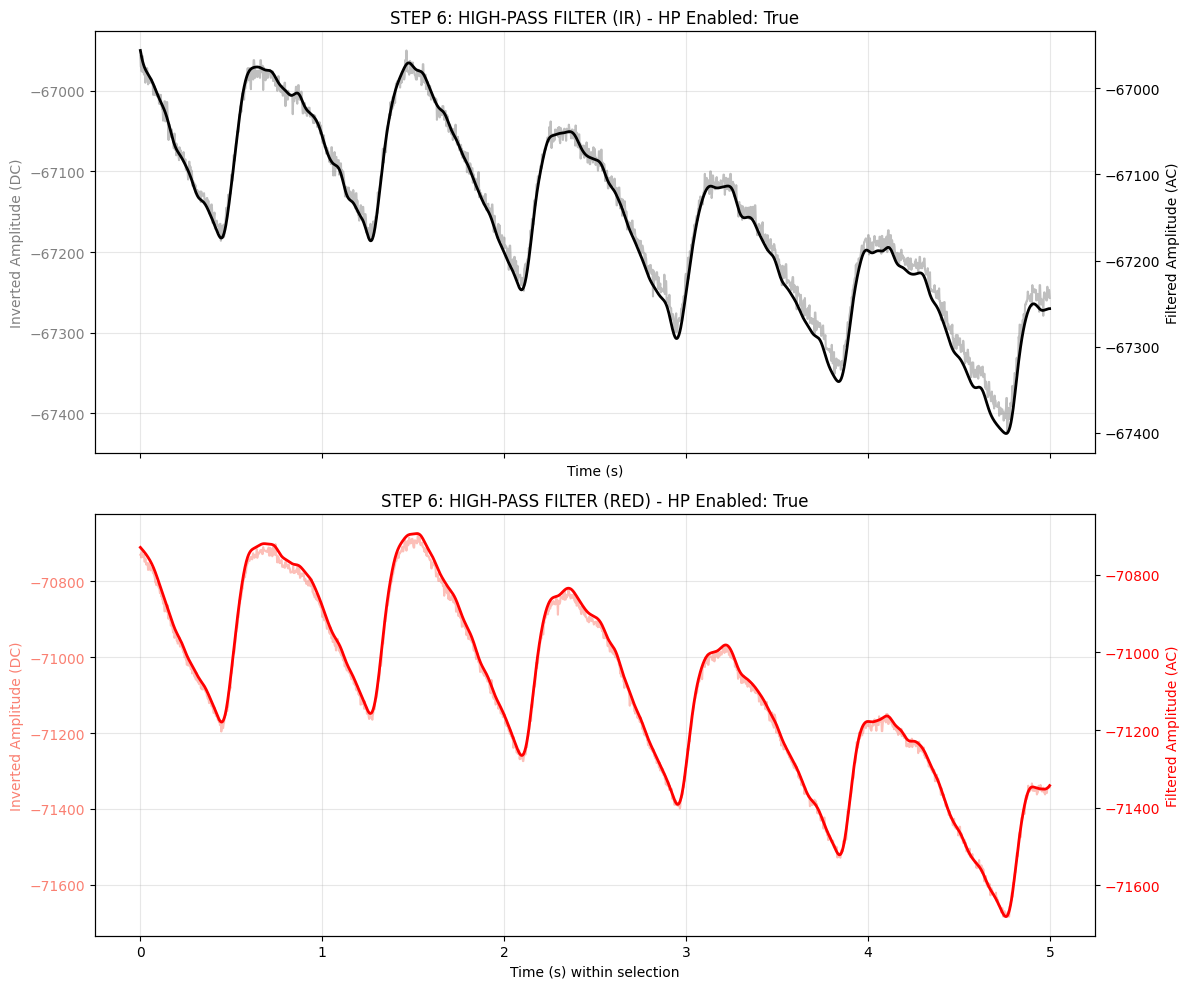

In [350]:
# ==========================================
# ⚙️ STEP 6: HIGH-PASS FILTER
# ==========================================
# Input: red_filtered / ir_filtered (Output from Step 5)
# Output: red_smoothed / ir_smoothed (Updated with HPF)

nyquist = 0.5 * FS

# --- Apply High Pass Filter (Conditional) ---
# Removes low freq drift (breathing/movement)
if HP_ENABLE:
    sos_hp = signal.butter(HP_ORDER, HP_CUTOFF / nyquist, btype='high', output='sos')
    
    # Input to HPF is the output of Step 5 (red_filtered)
    # We overwrite the variable with the further filtered version
    red_smoothed = signal.sosfiltfilt(sos_hp, red_filtered)
    ir_smoothed  = signal.sosfiltfilt(sos_hp, ir_filtered)
    print(f"⚠️ HPF Applied (Cutoff: {HP_CUTOFF}Hz). DC Offset Removed.")
else:
    # If HPF is off, we just keep the data from Step 5 as is
    print("ℹ️ HPF Disabled. Keeping DC Offset.")

# ==========================================
# 📊 PLOTTING (DC vs AC)
# ==========================================
t = np.arange(len(red_inverted)) / FS 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- Plot 1: IR Channel ---
# Left Axis: Inverted Input (Gray) - Shows the Baseline
color = 'gray'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Inverted Amplitude (DC)', color=color)
ax1.plot(t, ir_inverted, color=color, alpha=0.5, label='Inverted Input (Step 4)')
ax1.tick_params(axis='y', labelcolor=color)

# Right Axis: Filtered Output (Black) - Shows the Clean AC
ax1_right = ax1.twinx() 
color = 'black'
ax1_right.set_ylabel('Filtered Amplitude (AC)', color=color)
ax1_right.plot(t, ir_filtered, color=color, linewidth=2, label='High-Pass Output')
ax1_right.tick_params(axis='y', labelcolor=color)

ax1.set_title(f'STEP 6: HIGH-PASS FILTER (IR) - HP Enabled: {HP_ENABLE}')
ax1.grid(True, alpha=0.3)

# --- Plot 2: RED Channel ---
# Left Axis: Inverted Input (Salmon)
color = 'salmon'
ax2.set_xlabel('Time (s) within selection')
ax2.set_ylabel('Inverted Amplitude (DC)', color=color)
ax2.plot(t, red_inverted, color=color, alpha=0.5, label='Inverted Input (Step 4)')
ax2.tick_params(axis='y', labelcolor=color)

# Right Axis: Filtered Output (Red)
ax2_right = ax2.twinx()
color = 'red'
ax2_right.set_ylabel('Filtered Amplitude (AC)', color=color)
ax2_right.plot(t, red_filtered, color=color, linewidth=2, label='High-Pass Output')
ax2_right.tick_params(axis='y', labelcolor=color)

ax2.set_title(f'STEP 6: HIGH-PASS FILTER (RED) - HP Enabled: {HP_ENABLE}')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

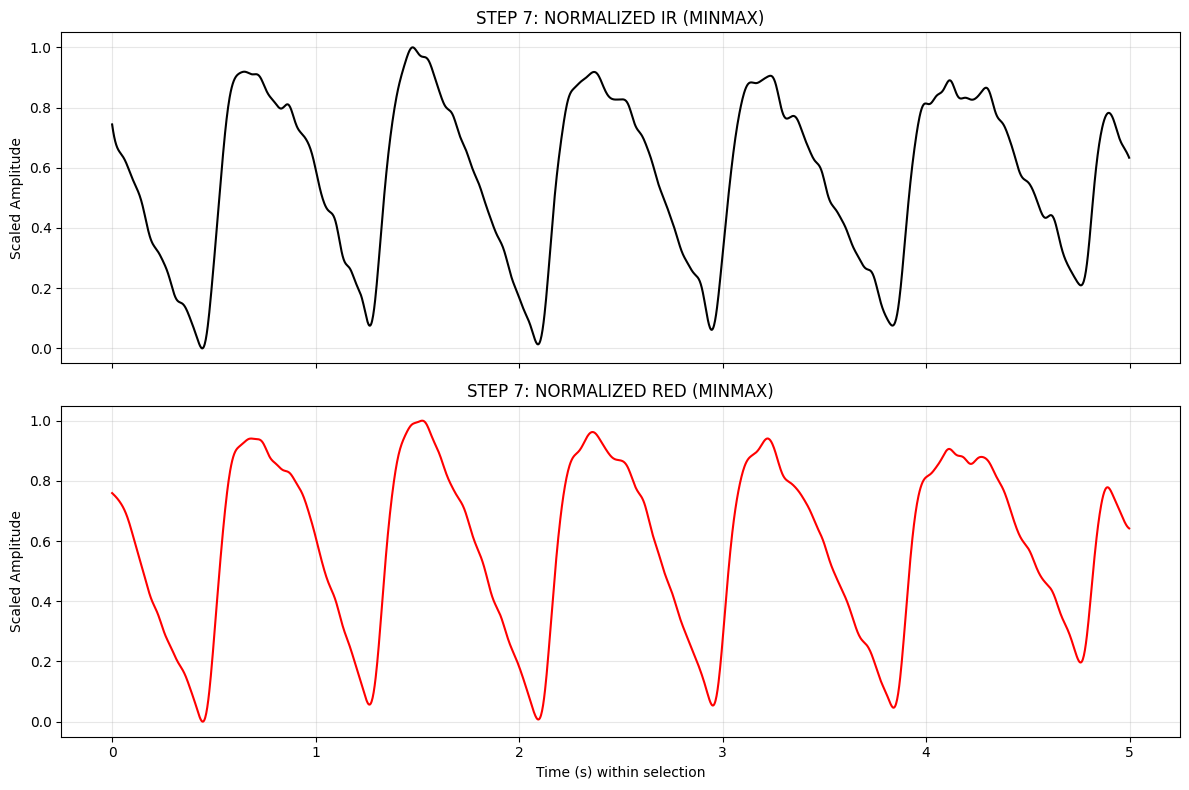

📊 Stats (MINMAX): Max: 1.00, Min: 0.00


In [351]:
# ==========================================
# ⚙️ STEP 7: NORMALIZATION
# ==========================================
# Input: red_smoothed / ir_smoothed (Output from Step 6.5) <--- UPDATED INPUT
# Output: red_final / ir_final

# Apply Normalization to the Fully Filtered Signal
red_final = apply_normalization(red_smoothed, method=NORM_METHOD)
ir_final  = apply_normalization(ir_smoothed, method=NORM_METHOD)

# Plot for Step 7
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(t, ir_final, color='black', linewidth=1.5)
ax1.set_title(f'STEP 7: NORMALIZED IR ({NORM_METHOD})')
ax1.set_ylabel('Scaled Amplitude')
ax1.grid(True, alpha=0.3)

ax2.plot(t, red_final, color='red', linewidth=1.5)
ax2.set_title(f'STEP 7: NORMALIZED RED ({NORM_METHOD})')
ax2.set_ylabel('Scaled Amplitude')
ax2.set_xlabel('Time (s) within selection')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Stats ({NORM_METHOD}): Max: {np.max(red_final):.2f}, Min: {np.min(red_final):.2f}")

In [352]:
# ==========================================
# ⚙️ STEP 8: ADVANCED SIGNAL QUALITY CHECK (High Standard)
# ==========================================
def calculate_snr(signal_data, fs):
    """
    Calculates Spectral Signal-to-Noise Ratio (SNR).
    Signal Power: 0.5 Hz to 5.0 Hz (Heartbeat range)
    Noise Power: Everything else.
    """
    freqs, psd = signal.periodogram(signal_data, fs)
    sig_mask = (freqs >= 0.5) & (freqs <= 5.0)
    noise_mask = ~sig_mask 
    sig_power = np.sum(psd[sig_mask])
    noise_power = np.sum(psd[noise_mask])
    if noise_power == 0: return 100.0
    return 10 * np.log10(sig_power / noise_power)

def calculate_zcr(signal_data):
    """ Measures how 'jittery' the signal is. """
    centered = signal_data - np.mean(signal_data)
    crossings = np.diff(np.signbit(centered)).sum()
    return crossings / len(signal_data)

def check_quality_advanced(name, clean_sig, raw_sig_for_dc, fs):
    print(f"\n📋 HIGH-STANDARD QUALITY REPORT: {name}")
    print("=" * 95)
    
    # --- 1. SKEWNESS (Shape Symmetry) ---
    # Healthy PPG has sharp systolic peaks => Positive Skewness (> 0.2)
    skew = stats.skew(clean_sig)
    skew_target = "> 0.2000"
    skew_status = "✅ PASS" if skew > 0.2 else "❌ FAIL (Too Flat/Inverted)"
    
    # --- 2. KURTOSIS (Peak Sharpness) ---
    # Healthy PPG is "peaky" => Positive Kurtosis (> 0.0)
    kurt = stats.kurtosis(clean_sig)
    kurt_target = "> 0.0000"
    kurt_status = "✅ PASS" if kurt > 0.0 else "⚠️ WARNING (Platykurtic)"
    
    # --- 3. PERFUSION INDEX (Signal Strength) ---
    # PI = (AC / DC) * 100
    ac_amp = np.max(clean_sig) - np.min(clean_sig)
    dc_amp = np.mean(raw_sig_for_dc)
    pi = (ac_amp / dc_amp) * 100 if dc_amp != 0 else 0
    pi_target = "> 0.1000 %"
    pi_status = "✅ PASS" if pi > 0.1 else "❌ FAIL (Too Weak)"

    # --- 4. SIGNAL-TO-NOISE RATIO (SNR) ---
    # Good clinical PPG should be > 5 dB
    snr = calculate_snr(clean_sig, fs)
    snr_target = "> 5.0000 dB"
    snr_status = "✅ PASS" if snr > 5.0 else "❌ FAIL (Too Noisy)"

    # --- 5. ZERO-CROSSING RATE (Stability) ---
    # If ZCR is too high (> 0.05), it means the signal is just static noise
    zcr = calculate_zcr(clean_sig)
    zcr_target = "< 0.0500"
    zcr_status = "✅ PASS" if zcr < 0.05 else "⚠️ WARNING (Jittery)"

    # --- PRINT TABLE ---
    # Format: Metric | Value | Target | Status
    print(f"{'METRIC':<20} | {'VALUE':<12} | {'TARGET RANGE':<15} | {'STATUS':<25}")
    print("-" * 95)
    print(f"{'Skewness':<20} | {skew:<12.4f} | {skew_target:<15} | {skew_status}")
    print(f"{'Kurtosis':<20} | {kurt:<12.4f} | {kurt_target:<15} | {kurt_status}")
    print(f"{'Perfusion Index':<20} | {pi:<12.4f} | {pi_target:<15} | {pi_status}")
    print(f"{'SNR (dB)':<20} | {snr:<12.4f} | {snr_target:<15} | {snr_status}")
    print(f"{'Zero-Crossing':<20} | {zcr:<12.4f} | {zcr_target:<15} | {zcr_status}")
    print("=" * 95)

    # Global Verdict
    if "❌" in (skew_status + pi_status + snr_status):
        print(f"🚨 FINAL VERDICT: REJECTED (Bad Signal)")
    else:
        print(f"🎉 FINAL VERDICT: ACCEPTED (Ready for AI)")

# Run Checks using 'red_filtered' (Clean AC) and 'selected_df' (Raw DC)
check_quality_advanced("RED CHANNEL", red_final, selected_df['RED'].values, FS)
check_quality_advanced("IR CHANNEL ", ir_final, selected_df['IR'].values, FS)


📋 HIGH-STANDARD QUALITY REPORT: RED CHANNEL
METRIC               | VALUE        | TARGET RANGE    | STATUS                   
-----------------------------------------------------------------------------------------------
Skewness             | -0.3673      | > 0.2000        | ❌ FAIL (Too Flat/Inverted)
Kurtosis             | -1.1796      | > 0.0000        | ⚠️ WARNING (Platykurtic)
Perfusion Index      | 0.0014       | > 0.1000 %      | ❌ FAIL (Too Weak)
SNR (dB)             | 17.8656      | > 5.0000 dB     | ✅ PASS
Zero-Crossing        | 0.0060       | < 0.0500        | ✅ PASS
🚨 FINAL VERDICT: REJECTED (Bad Signal)

📋 HIGH-STANDARD QUALITY REPORT: IR CHANNEL 
METRIC               | VALUE        | TARGET RANGE    | STATUS                   
-----------------------------------------------------------------------------------------------
Skewness             | -0.3379      | > 0.2000        | ❌ FAIL (Too Flat/Inverted)
Kurtosis             | -1.1691      | > 0.0000        | ⚠️ WARNING (

In [353]:
import numpy as np
import scipy.stats as stats
from scipy.signal import find_peaks

# ==========================================
# STEP 9: Extract_glucose_features
# ==========================================
def extract_glucose_features(clean_ppg, raw_ppg, fs):
    """
    Extract AI-ready features from PPG signal for glucose prediction.
    """
    # 1. Heart Rate (from peak detection)
    peaks, _ = find_peaks(clean_ppg, distance=int(0.4*fs))  # Min 150 BPM
    if len(peaks) > 1:
        avg_peak_interval = np.mean(np.diff(peaks)) / fs
        hr = 60.0 / avg_peak_interval if avg_peak_interval > 0 else 0
    else:
        hr = 0
    
    # 2. Pulse Width (Viscosity indicator)
    if len(peaks) > 0:
        widths = []
        for pk in peaks:
            half_max = clean_ppg[pk] * 0.5
            left = pk
            right = pk
            while left > 0 and clean_ppg[left] > half_max:
                left -= 1
            while right < len(clean_ppg)-1 and clean_ppg[right] > half_max:
                right += 1
            widths.append((right - left) / fs)
        avg_width = np.mean(widths) if widths else 0
    else:
        avg_width = 0
    
    # 3. Systolic Amplitude (Peak height)
    sys_amp = np.max(clean_ppg) - np.min(clean_ppg)
    
    # 4. Area Under Curve (Blood volume)
    # Note: Using np.trapezoid is preferred in newer NumPy, but trapz works for older versions
    if hasattr(np, 'trapezoid'):
        area = np.trapezoid(clean_ppg)
    else:
        area = np.trapz(clean_ppg)
    
    # 5. Skewness (Shape asymmetry)
    skew = stats.skew(clean_ppg)
    
    # 6. Kurtosis (Peak sharpness)
    kurt = stats.kurtosis(clean_ppg)
    
    # 7. Perfusion Index
    ac = sys_amp
    dc = np.mean(raw_ppg)
    pi = (ac / dc) * 100 if dc > 0 else 0
    
    return {
        'hr': hr,
        'width': avg_width,
        'sys_amp': sys_amp,
        'area': area,
        'skew': skew,
        'kurt': kurt,
        'pi': pi
    }

# ==========================================
# 2. RUN EXTRACTION & GENERATE REPORT
# ==========================================
print("\n🧬 EXTRACTING AI FEATURES...")

# Ensure inputs are correct (using variables from previous steps)
feat_red = extract_glucose_features(red_final, selected_df['RED'].values, FS)
feat_ir  = extract_glucose_features(ir_final, selected_df['IR'].values, FS)

# Calculate Ratio
if feat_ir['pi'] > 0:
    ratio_of_ratios = feat_red['pi'] / feat_ir['pi']
else:
    ratio_of_ratios = 0

# ==========================================
# 3. ENGINEER'S REPORT (Readable Output)
# ==========================================
print("\n" + "="*85)
print(f"📊 PPG FEATURE EXTRACTION REPORT")
print("="*85)
print(f"{'FEATURE':<25} | {'RED CHANNEL':<15} | {'IR CHANNEL':<15} | {'UNIT & MEANING'}")
print("-" * 85)

# 1. Heart Rate
print(f"{'Heart Rate (HR)':<25} | {feat_red['hr']:<15.1f} | {feat_ir['hr']:<15.1f} | BPM (Should match)")

# 2. Pulse Width (Viscosity)
print(f"{'Pulse Width':<25} | {feat_red['width']:<15.4f} | {feat_ir['width']:<15.4f} | Seconds (High Glucose -> Wider)")

# 3. Systolic Amplitude
print(f"{'Systolic Amp':<25} | {feat_red['sys_amp']:<15.4f} | {feat_ir['sys_amp']:<15.4f} | Normalized Height (0-1)")

# 4. Area Under Curve
print(f"{'Area Under Curve':<25} | {feat_red['area']:<15.4f} | {feat_ir['area']:<15.4f} | Total Blood Volume")

# 5. Skewness
print(f"{'Skewness':<25} | {feat_red['skew']:<15.4f} | {feat_ir['skew']:<15.4f} | >0 means Sharp Peaks")

# 6. Kurtosis
print(f"{'Kurtosis':<25} | {feat_red['kurt']:<15.4f} | {feat_ir['kurt']:<15.4f} | Peak Sharpness")

# 7. Perfusion Index
print(f"{'Perfusion Index (PI)':<25} | {feat_red['pi']:<15.4f} | {feat_ir['pi']:<15.4f} | % (Signal Strength)")

print("-" * 85)
print(f"🧪 FINAL 'R' VALUE (RATIO):  {ratio_of_ratios:.4f}")
print("   (Use this value to train your Glucose Prediction Model)")
print("="*85)


🧬 EXTRACTING AI FEATURES...

📊 PPG FEATURE EXTRACTION REPORT
FEATURE                   | RED CHANNEL     | IR CHANNEL      | UNIT & MEANING
-------------------------------------------------------------------------------------
Heart Rate (HR)           | 71.3            | 70.6            | BPM (Should match)
Pulse Width               | 0.5017          | 0.5008          | Seconds (High Glucose -> Wider)
Systolic Amp              | 1.0000          | 1.0000          | Normalized Height (0-1)
Area Under Curve          | 1151.1288       | 1126.4645       | Total Blood Volume
Skewness                  | -0.3673         | -0.3379         | >0 means Sharp Peaks
Kurtosis                  | -1.1796         | -1.1691         | Peak Sharpness
Perfusion Index (PI)      | 0.0014          | 0.0015          | % (Signal Strength)
-------------------------------------------------------------------------------------
🧪 FINAL 'R' VALUE (RATIO):  0.9445
   (Use this value to train your Glucose Prediction Mo

In [354]:
# ==========================================
# 🧪 STEP : REVISED SYMMETRY CHECK
# ==========================================
def check_symmetry_revised(signal_data, fs):
    print("\n🔍 CHECKING SYMMETRY (REVISED)...")
    
    # 1. Find Peaks & Valleys
    peaks, _ = signal.find_peaks(signal_data, distance=fs*0.5)
    valleys, _ = signal.find_peaks(-signal_data, distance=fs*0.5)
    
    if len(peaks) < 2 or len(valleys) < 2:
        print("❌ FAIL: Not enough peaks found.")
        return

    # 2. Measure First Full Cycle
    # Logic: Valley_1 -> Peak -> Valley_2
    v1 = valleys[0]
    # Find the first peak AFTER v1
    next_peaks = peaks[peaks > v1]
    if len(next_peaks) == 0: 
        print("❌ FAIL: No peak found after first valley.")
        return
    p1 = next_peaks[0]
    
    # Find the first valley AFTER p1
    next_valleys = valleys[valleys > p1]
    if len(next_valleys) == 0:
        print("❌ FAIL: Cycle incomplete.")
        return
    v2 = next_valleys[0]
        
    rise_samples = p1 - v1
    fall_samples = v2 - p1
    
    rise_time = rise_samples / fs
    fall_time = fall_samples / fs
    ratio = rise_time / fall_time
    
    total_duration = rise_time + fall_time
    bpm = 60.0 / total_duration
    
    print(f"⏱️ RISE Time: {rise_time:.3f}s (Systole - Pumping)")
    print(f"⏱️ FALL Time: {fall_time:.3f}s (Diastole - Filling)")
    print(f"❤️ Est. HR:  {bpm:.1f} BPM")
    print(f"⚖️ RATIO:     {ratio:.2f}")

    # 3. INTELLIGENT VERDICT
    if 0.10 <= ratio <= 0.60:
        print("✅ VERDICT: EXCELLENT (Healthy Shark-Fin Shape)")
        print("   The rise is fast and sharp. Perfect for Glucose ML.")
        
    elif ratio > 0.8:
        print("⚠️ VERDICT: BAD (Sine Wave / Over-Smoothed)")
        print("   Rise and Fall are too similar. Check Filter settings.")
        
    elif ratio < 0.10:
        print("⚠️ VERDICT: WARNING (Too Spiky / Noise?)")
        print("   Rise is suspiciously fast. Check for electrical noise spikes.")
        
# Run Revised Check
check_symmetry_revised(red_final, FS)


🔍 CHECKING SYMMETRY (REVISED)...
⏱️ RISE Time: 0.237s (Systole - Pumping)
⏱️ FALL Time: 0.583s (Diastole - Filling)
❤️ Est. HR:  73.2 BPM
⚖️ RATIO:     0.41
✅ VERDICT: EXCELLENT (Healthy Shark-Fin Shape)
   The rise is fast and sharp. Perfect for Glucose ML.


📉 Plotting RED Channel Distribution...


C:\Users\DELL\AppData\Local\Temp\ipykernel_12988\3249190391.py:51: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\DELL\ESP32_and_MAX30102\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


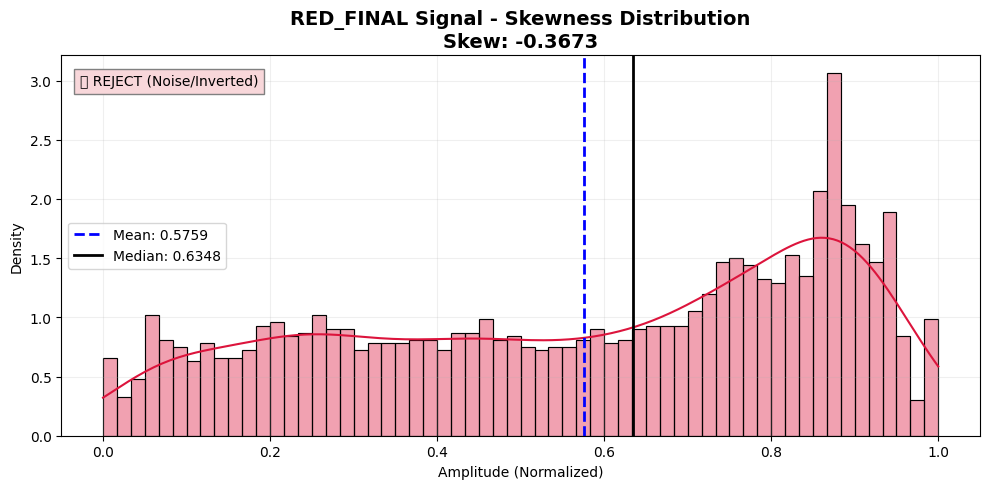

📉 Plotting IR Channel Distribution...


C:\Users\DELL\AppData\Local\Temp\ipykernel_12988\3249190391.py:51: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\DELL\ESP32_and_MAX30102\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


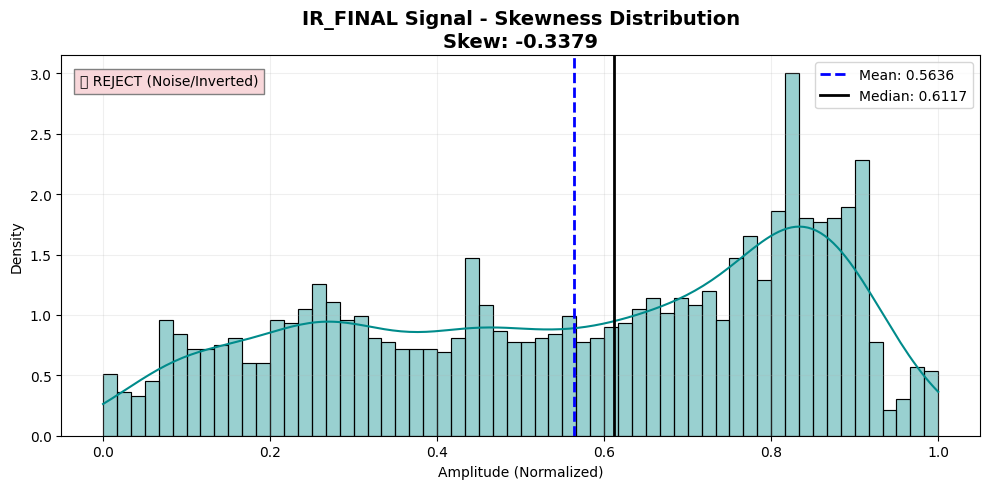

In [355]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def plot_skewness_visual(signal_data, signal_name):
    """
    Plots the Histogram and KDE to visualize Skewness for specific channels.
    """
    # 1. Safety: Flatten the data (handles Pandas Series or 2D arrays)
    clean_data = np.ravel(signal_data)
    
    # 2. Calculate Statistics
    skew_val = stats.skew(clean_data)
    mean_val = np.mean(clean_data)
    median_val = np.median(clean_data)
    
    # 3. Setup Plot
    plt.figure(figsize=(10, 5))
    
    # 4. Plot Histogram & KDE
    # Color logic: Red for Red Channel, Dark Cyan for IR Channel
    color = 'crimson' if "RED" in signal_name.upper() else 'darkcyan'
    sns.histplot(clean_data, kde=True, color=color, stat='density', bins=60, alpha=0.4)
    
    # 5. Vertical Lines for Mean vs Median
    plt.axvline(mean_val, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
    plt.axvline(median_val, color='black', linestyle='-', linewidth=2, label=f'Median: {median_val:.4f}')
    
    # 6. Labels and Verdict
    plt.title(f'{signal_name} - Skewness Distribution\nSkew: {skew_val:.4f}', fontsize=14, fontweight='bold')
    plt.xlabel('Amplitude (Normalized)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.2)
    
    # 7. Add Verdict Text Box
    if skew_val > 0.2:
        verdict = "✅ EXCELLENT (Sharp Systolic Peaks)"
        box_color = '#d4edda' # Light Green
    elif skew_val > 0:
        verdict = "⚠️ ACCEPTABLE (Slightly Flat)"
        box_color = '#fff3cd' # Light Yellow
    else:
        verdict = "❌ REJECT (Noise/Inverted)"
        box_color = '#f8d7da' # Light Red
        
    plt.text(0.02, 0.95, verdict, transform=plt.gca().transAxes, 
             bbox=dict(facecolor=box_color, alpha=1.0, edgecolor='gray'), fontsize=10, verticalalignment='top')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 🚀 EXECUTION BLOCK (Your Specific Inputs)
# ==========================================

# 1. Visualize RED Channel Final Output
# (Checks if the variable exists to prevent crash if you haven't run previous cells)
try:
    print("📉 Plotting RED Channel Distribution...")
    plot_skewness_visual(red_final, "RED_FINAL Signal")
except NameError:
    print("⚠️ Error: 'red_final' not found. Please run your filtering code first.")

# 2. Visualize IR Channel Final Output
try:
    print("📉 Plotting IR Channel Distribution...")
    plot_skewness_visual(ir_final, "IR_FINAL Signal")
except NameError:
    print("⚠️ Error: 'ir_final' not found. Please run your filtering code first.")

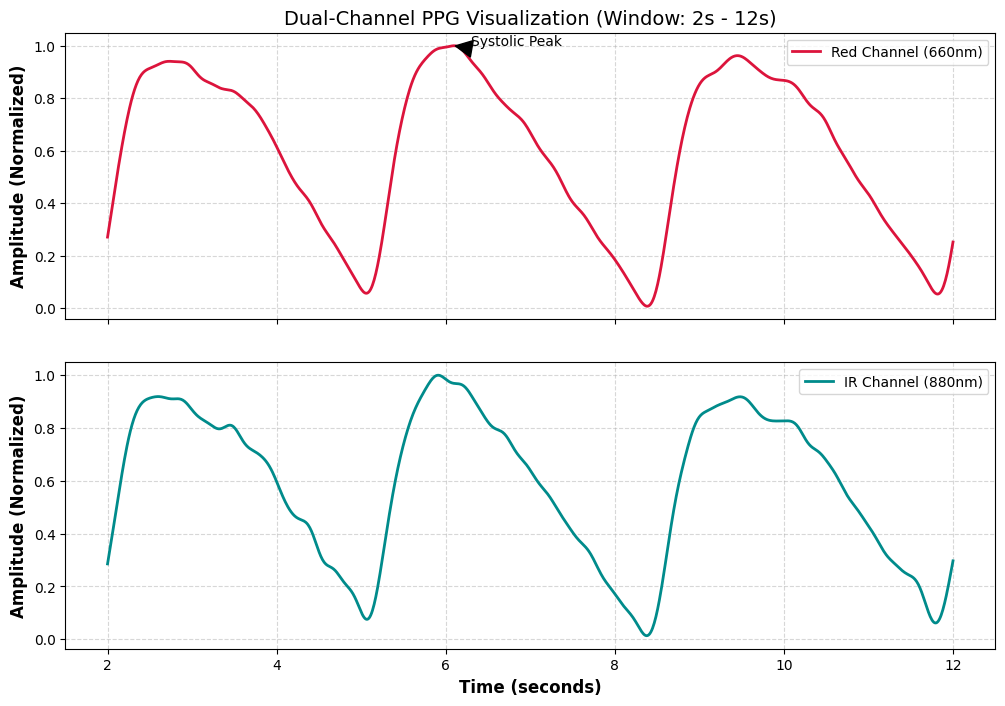

In [356]:
import numpy as np
import matplotlib.pyplot as plt

def plot_dual_ppg(red_sig, ir_sig, fs=100, duration_sec=3, start_sec=0):
    """
    Plots RED and IR signals on stacked subplots to compare morphology.
    
    Parameters:
    - red_sig, ir_sig: The input data arrays (lists or numpy arrays).
    - fs: Sampling Frequency (default 100Hz for typical MAX30102).
    - duration_sec: How many seconds of data to zoom in on (default 3s).
    - start_sec: Where to start the window (default 0s).
    """
    
    # 1. Safety Check: Ensure data is flat
    red_clean = np.ravel(red_sig)
    ir_clean = np.ravel(ir_sig)
    
    # 2. Calculate Sample Indices for the Zoom Window
    start_idx = int(start_sec * fs)
    end_idx = int((start_sec + duration_sec) * fs)
    
    # Prevent crashing if window is larger than data
    if end_idx > len(red_clean):
        end_idx = len(red_clean)
        print("⚠️ Warning: Requested duration exceeds data length. Showing available data.")

    # 3. Slice the Data
    y_red = red_clean[start_idx:end_idx]
    y_ir = ir_clean[start_idx:end_idx]
    
    # Create Time Axis (in seconds)
    t = np.linspace(start_sec, start_sec + (len(y_red)/fs), len(y_red))

    # 4. Setup Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    plt.subplots_adjust(hspace=0.15) # Less space between plots

    # --- TOP PLOT: RED CHANNEL ---
    ax1.plot(t, y_red, color='crimson', linewidth=2, label='Red Channel (660nm)')
    ax1.set_ylabel('Amplitude (Normalized)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Dual-Channel PPG Visualization (Window: {start_sec}s - {start_sec+duration_sec}s)', fontsize=14)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper right')
    
    # Add annotation for a Peak (Visual Guide)
    if len(y_red) > 0:
        peak_idx = np.argmax(y_red)
        ax1.annotate('Systolic Peak', xy=(t[peak_idx], y_red[peak_idx]), 
                     xytext=(t[peak_idx]+0.2, y_red[peak_idx]),
                     arrowprops=dict(facecolor='black', shrink=0.05))

    # --- BOTTOM PLOT: INFRARED CHANNEL ---
    # We flip IR visualization sometimes if raw data is inverted, but assuming 'final' is corrected.
    ax2.plot(t, y_ir, color='darkcyan', linewidth=2, label='IR Channel (880nm)')
    ax2.set_ylabel('Amplitude (Normalized)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='upper right')

    plt.show()

# ==========================================
# 🚀 EXECUTION BLOCK
# ==========================================
# Adjust 'start_sec' to scroll through your signal!
# Example: Look at the data from second 5 to second 8.

try:
    plot_dual_ppg(red_final, ir_final, fs=100, duration_sec=10, start_sec=2)
except NameError:
    print("⚠️ Error: Variables 'red_final' or 'ir_final' not found.")